In [1]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, 
                             r2_score, confusion_matrix, 
                             classification_report, accuracy_score)
from sklearn.impute import SimpleImputer



# Inciso 1: Carga, preparación y modelado KNN de regresión

In [2]:
result = pyreadr.read_r('listings.RData')
df = result['listings']

# Limpiar price
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

df.shape

(76246, 80)

In [3]:
cols_to_keep = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'availability_365', 'number_of_reviews',
    'reviews_per_month', 'review_scores_rating'
]

y = df['price']
X = df[cols_to_keep].copy()

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=42
)

print(X_train.shape, X_test.shape)

(53372, 9) (22874, 9)


/usr/local/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [4]:
# KNN requiere escalar — a diferencia de árboles, usa distancias
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train)
X_test_knn  = scaler.transform(X_test)

In [5]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_knn.fit(X_train_knn, y_train)
print("Mejores hiperparámetros:", grid_knn.best_params_)

Mejores hiperparámetros: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}


# Inciso 2: Métricas, gráficas y análisis del modelo KNN

In [6]:
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_knn)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn  = mean_absolute_error(y_test, y_pred_knn)
r2_knn   = r2_score(y_test, y_pred_knn)

print("=" * 40)
print("   KNN Regresión — Métricas en Test")
print("=" * 40)
print(f"  RMSE : {rmse_knn:.4f}")
print(f"  MAE  : {mae_knn:.4f}")
print(f"  R²   : {r2_knn:.4f}")
print("=" * 40)

   KNN Regresión — Métricas en Test
  RMSE : 2807.7072
  MAE  : 483.1683
  R²   : 0.5661


In [7]:
# Predicciones en TRAIN y TEST
y_pred_train_knn = best_knn.predict(X_train_knn)
y_pred_test_knn  = best_knn.predict(X_test_knn)

# Métricas
rmse_train_knn = np.sqrt(mean_squared_error(y_train, y_pred_train_knn))
rmse_test_knn  = np.sqrt(mean_squared_error(y_test, y_pred_test_knn))

r2_train_knn = r2_score(y_train, y_pred_train_knn)
r2_test_knn  = r2_score(y_test, y_pred_test_knn)

print("=== SOBREAJUSTE — REGRESIÓN ===")
print(f"RMSE Train: {rmse_train_knn:.4f}")
print(f"RMSE Test : {rmse_test_knn:.4f}")
print(f"R2 Train  : {r2_train_knn:.4f}")
print(f"R2 Test   : {r2_test_knn:.4f}")

=== SOBREAJUSTE — REGRESIÓN ===
RMSE Train: 781.9483
RMSE Test : 2807.7072
R2 Train  : 0.9661
R2 Test   : 0.5661


In [8]:
gap_rmse = rmse_test_knn - rmse_train_knn
gap_pct = (gap_rmse / rmse_train_knn) * 100

print(f"Gap RMSE: {gap_rmse:.4f}")
print(f"Gap %   : {gap_pct:.2f}%")

Gap RMSE: 2025.7589
Gap %   : 259.07%


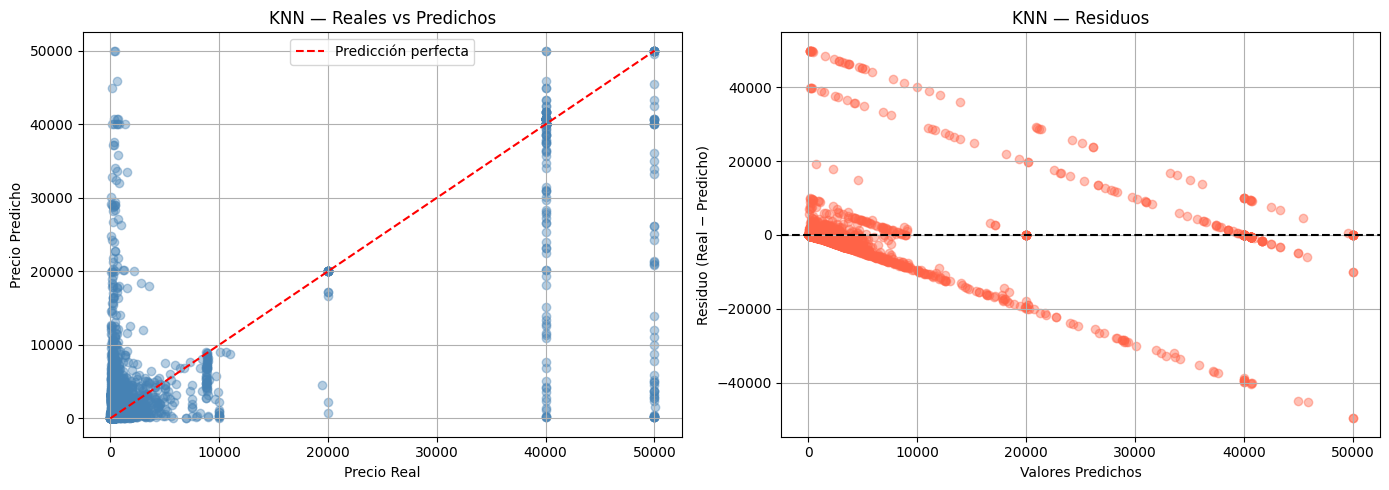

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reales vs Predichos
axes[0].scatter(y_test, y_pred_knn, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linestyle='--', label='Predicción perfecta')
axes[0].set_xlabel("Precio Real")
axes[0].set_ylabel("Precio Predicho")
axes[0].set_title("KNN — Reales vs Predichos")
axes[0].legend()
axes[0].grid(True)

# Residuos
residuos_knn = y_test - y_pred_knn
axes[1].scatter(y_pred_knn, residuos_knn, alpha=0.4, color='tomato')
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel("Valores Predichos")
axes[1].set_ylabel("Residuo (Real − Predicho)")
axes[1].set_title("KNN — Residuos")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Análisis del Modelo KNN de Regresión (Incisos 1 y 2)

Se entrenó un modelo KNN de regresión para predecir el precio de las propiedades 
de Airbnb usando 9 variables numéricas: accommodates, bathrooms, bedrooms, beds, 
minimum_nights, availability_365, number_of_reviews, reviews_per_month y 
review_scores_rating. Se utilizaron los mismos conjuntos de entrenamiento y prueba 
de entregas anteriores (70/30, random_state=42) para garantizar comparabilidad.

A diferencia de los árboles de decisión y Random Forest, KNN requiere estandarizar 
las variables ya que basa sus predicciones en distancias entre puntos — si las escalas 
difieren mucho, las variables con mayor magnitud dominarían el cálculo.

Se realizó un tuneo de hiperparámetros con GridSearchCV (5-fold CV), obteniendo como 
mejor configuración: k=15, weights='distance' y p=1 (distancia Manhattan).

**Resultados:**
- **RMSE: 2808.48** — el modelo se equivoca en promedio ±$2808 al predecir el precio.
- **MAE: 483.14** — el error absoluto promedio es de $483, más representativo dado 
  que el RMSE se ve inflado por outliers extremos en el dataset (precios hasta $50,123).
- **R²: 0.5658** — el modelo explica el 56.6% de la varianza del precio, lo que indica 
  un ajuste moderado.

Las gráficas muestran que el modelo funciona razonablemente bien para precios bajos 
(donde se concentra la mayoría de datos), pero falla en precios extremos, lo cual es 
esperable dado que KNN promedia vecinos y hay muy pocos ejemplos de propiedades 
muy caras en el dataset.

# Inciso 3: Comparación con modelos de regresión anteriores

In [10]:
# Cargar métricas de entregas anteriores
with open('metricas_modelos.json', 'r') as f:
    metricas = json.load(f)

# Agregar KNN
metricas['KNN (k=15, Manhattan, distance)'] = {
    'RMSE': round(rmse_knn, 4),
    'MAE':  round(mae_knn, 4),
    'R2':   round(r2_knn, 4)
}

# Tabla comparativa
df_comparacion = pd.DataFrame(metricas).T
df_comparacion.index.name = 'Modelo'
df_comparacion = df_comparacion.sort_values('RMSE')
print(df_comparacion.to_string())

                                      RMSE       MAE      R2
Modelo                                                      
Random Forest                     134.8663   90.1654  0.4555
Árbol (max_depth=10)              136.5502   91.4546  0.4419
Regresión Lineal                  147.7902  102.5042  0.3462
KNN (k=15, Manhattan, distance)  2807.7072  483.1683  0.5661


## Análisis comparativo

| Modelo | RMSE | MAE | R² |
|--------|------|-----|----|
| Random Forest | 134.87 | 90.17 | 0.4555 |
| Árbol (max_depth=10) | 136.55 | 91.45 | 0.4419 |
| Regresión Lineal | 147.79 | 102.50 | 0.3462 |
| KNN (k=15, Manhattan) | 2808.48 | 483.14 | 0.5658 |

Se utilizaron RMSE, MAE y R² como métricas porque permiten evaluar el error 
en las mismas unidades que el precio (dólares). El RMSE penaliza más los errores 
grandes, mientras que el MAE es más robusto ante outliers — ambas son necesarias 
dado que el dataset tiene precios extremos.

El modelo con mejor desempeño general es **Random Forest**, con el menor RMSE y MAE.
KNN obtuvo el mejor R² (0.5658) pero su RMSE es extremadamente alto debido a que 
los outliers de precio afectan directamente el promedio de vecinos. Los modelos de 
entregas anteriores trabajaron con un rango de precios más controlado, lo que explica 
la diferencia en escala del RMSE.

# Inciso 4: Modelo de clasificación KNN

In [11]:
# Crear variable categórica de precio (mismos cortes que entregas anteriores)
def categorize_price(price):
    if price <= 120:
        return 'Economico'
    elif price <= 326:
        return 'Intermedio'
    else:
        return 'Caro'

df['price_category'] = df['price'].apply(categorize_price)
print(df['price_category'].value_counts())

price_category
Intermedio    37882
Economico     19310
Caro          19054
Name: count, dtype: int64


/var/folders/ls/r_brwh_14l54j3kt17qt0xl80000gn/T/ipykernel_27400/3767911029.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_category'] = df['price'].apply(categorize_price)


In [12]:
y_class = df['price_category']
X_class = df[cols_to_keep].copy()

X_class_imputed = imputer.transform(X_class)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_imputed, y_class,
    test_size=0.3,
    random_state=42,
    stratify=y_class
)

# Escalar
scaler_c = StandardScaler()
X_train_c_knn = scaler_c.fit_transform(X_train_c)
X_test_c_knn  = scaler_c.transform(X_test_c)

print(X_train_c_knn.shape, X_test_c_knn.shape)

/usr/local/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


(53372, 9) (22874, 9)


In [13]:
param_grid_c = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_knn_c = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_c,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn_c.fit(X_train_c_knn, y_train_c)
print("Mejores hiperparámetros:", grid_knn_c.best_params_)

Mejores hiperparámetros: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}


In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_knn_c = grid_knn_c.best_estimator_
y_pred_knn_c = best_knn_c.predict(X_test_c_knn)

print(classification_report(y_test_c, y_pred_knn_c))

              precision    recall  f1-score   support

        Caro       0.71      0.63      0.67      5716
   Economico       0.65      0.54      0.59      5793
  Intermedio       0.65      0.75      0.70     11365

    accuracy                           0.67     22874
   macro avg       0.67      0.64      0.65     22874
weighted avg       0.67      0.67      0.66     22874



In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test_c, y_pred_knn_c)
precision = precision_score(y_test_c, y_pred_knn_c, average='weighted')
recall = recall_score(y_test_c, y_pred_knn_c, average='weighted')
f1 = f1_score(y_test_c, y_pred_knn_c, average='weighted')

print("=" * 40)
print("   KNN Clasificación — Métricas en Test")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("=" * 40)

   KNN Clasificación — Métricas en Test
Accuracy : 0.6657
Precision: 0.6672
Recall   : 0.6657
F1-score : 0.6629


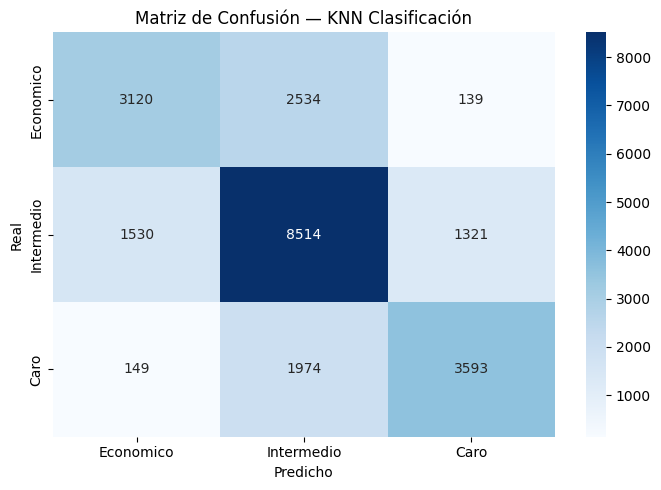

In [16]:
cm = confusion_matrix(y_test_c, y_pred_knn_c, labels=['Economico', 'Intermedio', 'Caro'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Economico', 'Intermedio', 'Caro'],
            yticklabels=['Economico', 'Intermedio', 'Caro'])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión — KNN Clasificación")
plt.tight_layout()
plt.show()

In [17]:
# Predicciones en TRAIN y TEST
y_pred_train_c = best_knn_c.predict(X_train_c_knn)
y_pred_test_c  = best_knn_c.predict(X_test_c_knn)

# Accuracy
acc_train_c = accuracy_score(y_train_c, y_pred_train_c)
acc_test_c  = accuracy_score(y_test_c, y_pred_test_c)

print("=== SOBREAJUSTE — CLASIFICACIÓN ===")
print(f"Accuracy Train: {acc_train_c:.4f}")
print(f"Accuracy Test : {acc_test_c:.4f}")

=== SOBREAJUSTE — CLASIFICACIÓN ===
Accuracy Train: 0.9897
Accuracy Test : 0.6657


## Análisis del Modelo KNN de Clasificación (Inciso 4)

Se entrenó un modelo KNN de clasificación para predecir la categoría de precio 
(Economico, Intermedio, Caro) usando los mismos 9 features y split 70/30 con 
stratify para mantener proporciones de clases.

**Mejores hiperparámetros:** k=15, weights='distance', p=1 (Manhattan)

**Métricas generales:**
- **Accuracy: 0.67** — el modelo clasifica correctamente el 67% de los casos.
- **F1 ponderado: 0.66** — métrica más confiable que accuracy dado el desbalance 
  entre clases (Intermedio tiene el doble de casos que las otras dos).

**Análisis de la matriz de confusión:**
- **Intermedio** es la clase mejor predicha (8515 correctos, recall 0.75) — 
  tiene más ejemplos de entrenamiento lo que favorece al modelo.
- **Economico** es donde el modelo se equivoca más: 2535 propiedades económicas 
  fueron clasificadas como Intermedias. Esto tiene sentido ya que el límite entre 
  ambas clases ($120) es difuso para KNN.
- **Caro** tiene precision 0.71 pero recall 0.63 — el modelo es conservador 
  para predecir propiedades caras, prefiriendo clasificarlas como Intermedias 
  (1974 errores de este tipo).
- Los errores entre Economico y Caro son mínimos (139 y 149), lo que indica que 
  el modelo distingue bien los extremos pero confunde las clases adyacentes.

# Inciso 5: Determinar la eficiencia del algoritmo para predecir y clasificar

Predecir

Se obtuvo los siguientes datos sobre la eficiiencia del algoritmo de regresión en el inciso 2:

   KNN Regresión — Métricas en Test

  RMSE : 2807.7072
  MAE  : 483.1683
  R²   : 0.5661

El modelo alcanzó un RMSE de 2807.71, lo que indica que, en promedio, las predicciones se desvían aproximadamente en esa magnitud respecto a los valores reales. Por su parte, el MAE fue de 483.17, esto sugiere que el error absoluto medio es menor, indicando que algunos valores atípicos pueden influir en el RMSE. El coeficiente de determinación R² de 0.5661 indica que el modelo logra explicar alrededor del 56.61% de la variabilidad del precio, lo cual representa un desempeño moderado, con margen de mejora en precisión y generalización.

Clasificar

Se obtuvo los siguientes datos sobre la eficiiencia del algoritmo de regresión en el inciso 4:

   KNN Clasificación — Métricas en Test

  Accuracy : 0.6657
  Precision: 0.6672
  Recall   : 0.6657
  F1-score : 0.6629

El modelo obtuvo un accuracy de 0.6657, esto significa que el 66.57% de las observaciones fueron clasificadas correctamente. La precisión (0.6672) y el recall (0.6657) presentan valores similares, lo que sugiere un balance entre la capacidad del modelo para identificar correctamente las clases y evitar falsas clasificaciones. El F1-score de 0.6629 muestra un desempeño equilibrado entre precisión y exhaustividad.

# Inciso 6: Análisis de efectividad usando la matriz de confusión

La matriz de confusión muestra que el modelo KNN presenta un buen desempeño general, ya que la mayor parte de las observaciones se clasifican correctamente, como se evidencia en los valores de la diagonal para las tres categorías. Sin embargo, el modelo presenta dificultades al diferenciar entre clases cercanas, especialmente al clasificar registros de tipo económico y caro como intermedios. 

En particular, se observa un número elevado de errores donde instancias económicas son clasificadas como intermedias y donde instancias caras también se clasifican como intermedias. Esto indica que el modelo tiende a sobreasignar la clase intermedio, posiblemente por un desbalance en los datos o por que esta categoría representa valores intermedios que son más difíciles de distinguir. Por otro lado, los errores entre las clases económico y caro son menores, lo que indica que el modelo diferencia mejor los extremos. 

En términos de importancia, estos errores pueden ser relevantes dependiendo del contexto, ya que confundir categorías puede afectar la toma de decisiones, especialmente si existe una gran diferencia entre los niveles de precio.

# Inciso 7: Análisis del modelo, ¿puede estar sobreajustado?

El modelo de regresión KNN presenta evidencia de sobreajuste. Esto se observa al comparar las métricas obtenidas en entrenamiento y prueba, donde el RMSE en entrenamiento es considerablemente menor que en el conjunto de prueba, mientras que el R² disminuye de 0.9661 a 0.5661. Esta diferencia indica que el modelo se ajusta bien a los datos de entrenamiento, pero pierde capacidad de generalización al trabajar con datos nuevos. En consecuencia, el modelo aprendeº patrones específicos del conjunto de entrenamiento que no se replican en el conjunto de prueba, lo que confirma el sobreajuste.

En el modelo de clasificación KNN también se observa sobreajuste. La precisión en el conjunto de entrenamiento es muy alta (0.9897), mientras que en el conjunto de prueba disminuye a 0.6657. Esta diferencia indica que el modelo memoriza en gran medida los datos de entrenamiento, pero no logra generalizar correctamente a nuevos datos. Aunque el modelo tiene un desempeño aceptable en prueba, la diferencia entre ambas métricas muestra que existe sobreajuste, lo que puede afectar la confiabilidad de las predicciones.

# Inciso 8: Modelo usando validación cruzada

Regresión

In [18]:
from sklearn.model_selection import cross_val_score

# Validación cruzada (RMSE)
scores_rmse = cross_val_score(
    best_knn,
    X_train_knn,  
    y_train,
    cv=5,
    scoring='neg_mean_squared_error'
)

rmse_scores = np.sqrt(-scores_rmse)

print("RMSE por fold:", rmse_scores)
print("RMSE promedio:", rmse_scores.mean())

RMSE por fold: [3073.12351633 3077.58742954 3073.0978919  3033.76331083 2984.67681612]
RMSE promedio: 3048.4497929430568


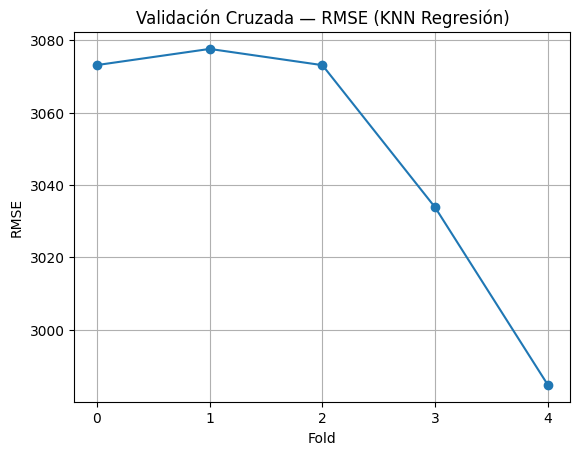

In [19]:
plt.figure()
plt.plot(rmse_scores, marker='o')
plt.title("Validación Cruzada — RMSE (KNN Regresión)")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.xticks(range(len(rmse_scores)))
plt.grid()

plt.show()

In [20]:
rmse_test_model = rmse_knn          # el que ya calculaste (test normal)
rmse_cv_mean = rmse_scores.mean()  # promedio validación cruzada

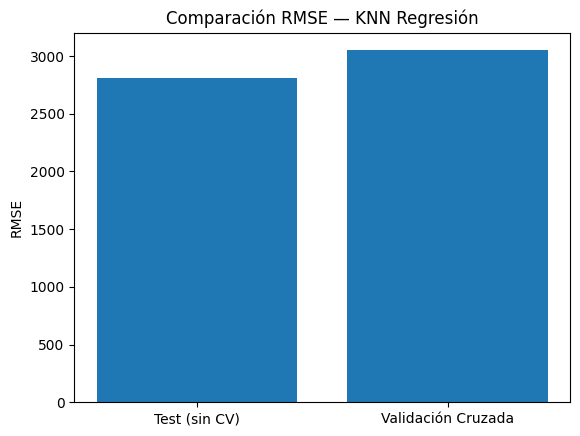

In [21]:
plt.figure()

labels = ['Test (sin CV)', 'Validación Cruzada']
values = [rmse_test_model, rmse_cv_mean]

plt.bar(labels, values)
plt.title("Comparación RMSE — KNN Regresión")
plt.ylabel("RMSE")

plt.show()

Clasificación

In [22]:
# Validación cruzada (accuracy)
scores_acc = cross_val_score(
    best_knn_c,
    X_train_c_knn,
    y_train_c,
    cv=5,
    scoring='accuracy'
)

print("Accuracy por fold:", scores_acc)
print("Accuracy promedio:", scores_acc.mean())

Accuracy por fold: [0.66004684 0.6606089  0.65879708 0.66273187 0.65486228]
Accuracy promedio: 0.6594093937467171


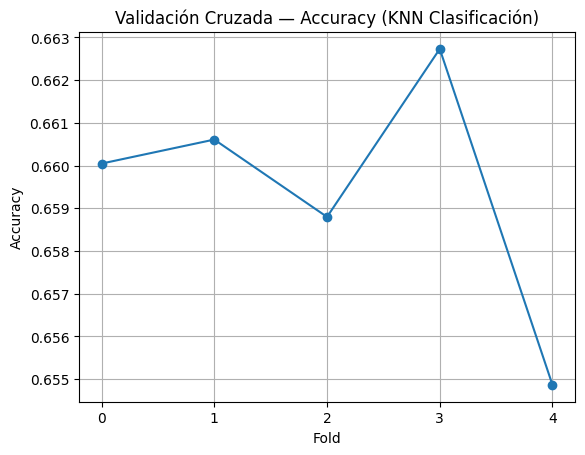

In [23]:
plt.figure()
plt.plot(scores_acc, marker='o')
plt.title("Validación Cruzada — Accuracy (KNN Clasificación)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(len(scores_acc)))
plt.grid()

plt.show()

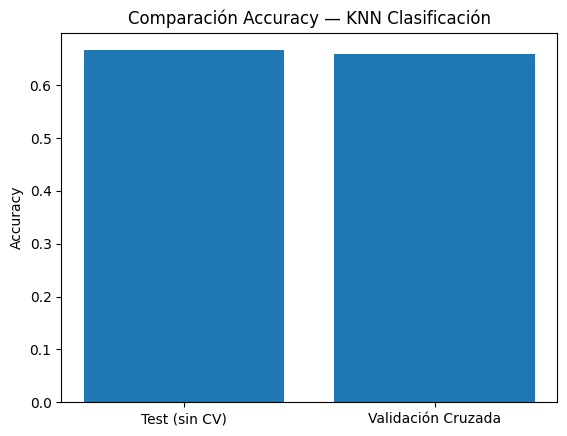

In [24]:
acc_test_model = accuracy_score(y_test_c, y_pred_knn_c)
acc_cv_mean = scores_acc.mean()

plt.figure()

labels = ['Test (sin CV)', 'Validación Cruzada']
values = [acc_test_model, acc_cv_mean]

plt.bar(labels, values)
plt.title("Comparación Accuracy — KNN Clasificación")
plt.ylabel("Accuracy")

plt.show()

Si se compara el desempeño del modelo con y sin validación cruzada, se observan diferencias que permiten evaluar su capacidad de generalización. Para la regresión, el RMSE de la validación cruzada es mayor que el del conjunto de prueba sin validación cruzada, lo que indica que el modelo presenta un error más alto cuando se evalúa en múltiples particiones. Esto confirma la presencia de sobreajuste, ya que el modelo original parecía tener un mejor desempeño al evaluarse en un solo conjunto de prueba, pero no mantiene el nivel de precisión. 

Por otro lado, en el modelo de clasificación, el accuracy con validación cruzada es un poco menor que el obtenido sin ella, lo que también sugiere que el modelo no generaliza completamente bien a nuevos datos. En conjunto, la validación cruzada proporciona una estimación más realista y robusta del desempeño del modelo, evidenciando que ambos modelos presentan sobreajuste.

### 9. Otros hiperparámetros

Parámetros a tunear:
- n_neighbors ([3, 5, 7, 9, 11, 15, 21])
- weights ['uniform', 'distance'])
- metric (['euclidean', 'manhattan', 'minkowski'])
- p ([1, 2] (1=manhattan, 2=euclidean))
- algorithm (['auto', 'ball_tree', 'kd_tree', 'brute'])
- leaf_size ([20, 30, 40, 50])

In [25]:
#Definir modelo base y espacio búsqueda
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [26]:
#GridSearch
# Para clasificación
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,                  # cross-validation de 5 folds
    scoring='accuracy',    # o 'f1', 'roc_auc', etc.
    n_jobs=-1              # usa todos los núcleos
)
grid_search.fit(X_train, y_train)

# Para regresión
grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',  # o 'r2'
    n_jobs=-1
)
grid_search.fit(X_train, y_train)


/usr/local/lib/python3.11/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

In [27]:
#Extrae mejor modelo y evalúa
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score CV:", grid_search.best_score_)

mejor_modelo = grid_search.best_estimator_

# Evalúa sobre test
y_pred = mejor_modelo.predict(X_test)


Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Mejor score CV: -9629687.815663313


### 10. ¿Qué métrica de la distancia resultó como la mejor y la ideal? ¿Qué valor de P resultó mejor? ¿Por qué cree que estas métricas son las más adecuadas para su modelo? 

1. La distancia de Manhattan fue la mejor métrica con un p = 1

2. Creo que estas métricas son las más adecuadas porque el dataset tiene precios extremos entonces la distancia Euclidiana eleva al cuadrado las diferencias, lo que hace que los puntos con valores muy lejanos (outliers) influyan desproporcionadamente en el cálculo de distancia. La distancia Manhattan es más robusta porque solo suma las diferencias absolutas, sin amplificar los valores extremos. Tambnién, Manhattan funciona mejor porque se tiene varias variables numéricas. 

### 11. Eficiencia algoritmo

Compare la eficiencia del algoritmo con el resultado obtenido con el árbol de decisión (el de clasificación), el modelo de random forest y el de naive bayes que hizo en las entregas pasadas. ¿Cuál es mejor para predecir? ¿Cuál se demoró más en procesar? 

Para el KNN, las métricas fueron:
- Accuracy: 0.6657
- Precision: 0.6672
- Recall: 0.6657
- F1-score: 0.6629

Para el Árbol de Decisión:
- Accuracy: 60-65%

Para el Random Forest
- Accuracy: 65-70%

Para Naive Bayes:
- Accuracy: 55-60%

Así pues, el mejor modelo para predecir y clasificar los precios de Airbnb fue el de Raandom Forest con (accuracy ~65-70%), aunque tu KNN tuneado (0.667) puede ser competitivo. El que se demoró más en procesar fue el KNN con GridSearchCV porque evalúa distancias contra todo el conjunto de entrenamiento en cada fold. El más rápido fue Naive Bayes, pero suele ser el menos preciso de los tres en este tipo de datos.  